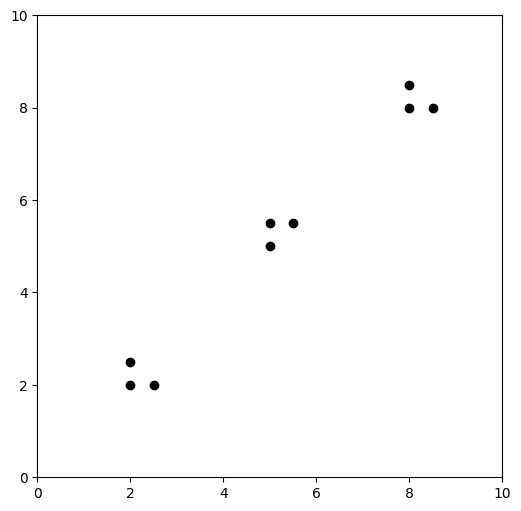

In [44]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
import time

points = [[2.0, 2.0], [2.5, 2.0], [2.0, 2.5], 
          [8.0, 8.0], [8.0, 8.5], [8.5, 8.0], 
          [5.0, 5.0], [5.5, 5.5], [5.0, 5.5]]

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)

def onclick(event):
    if event.xdata is None or event.ydata is None:
        return
    if event.button == 1:
        points.append([event.xdata, event.ydata])
        ax.plot(event.xdata, event.ydata, 'ko')
        fig.canvas.draw()
    elif event.button == 3:
        fig.canvas.mpl_disconnect(cid)
        plt.close(fig)

cid = fig.canvas.mpl_connect('button_press_event', onclick)
ax.plot([p[0] for p in points], [p[1] for p in points], 'ko')
plt.show()

In [45]:
X = np.array(points)
print(X)

[[2.  2. ]
 [2.5 2. ]
 [2.  2.5]
 [8.  8. ]
 [8.  8.5]
 [8.5 8. ]
 [5.  5. ]
 [5.5 5.5]
 [5.  5.5]]


In [46]:
class SimpleKMeans:
    def __init__(self, n_clusters, max_iter=300):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        
    def fit(self, X):
        np.random.seed(42)
        idx = np.random.choice(X.shape[0], self.n_clusters, replace=False)
        self.centroids = X[idx]
        
        for _ in range(self.max_iter):
            distances = np.sqrt(((X - self.centroids[:, np.newaxis])**2).sum(axis=2))
            self.labels = np.argmin(distances, axis=0)
            
            new_centroids = np.array([X[self.labels == i].mean(axis=0) if len(X[self.labels == i]) > 0 else self.centroids[i] for i in range(self.n_clusters)])
            
            if np.allclose(self.centroids, new_centroids):
                break
            self.centroids = new_centroids
        return self

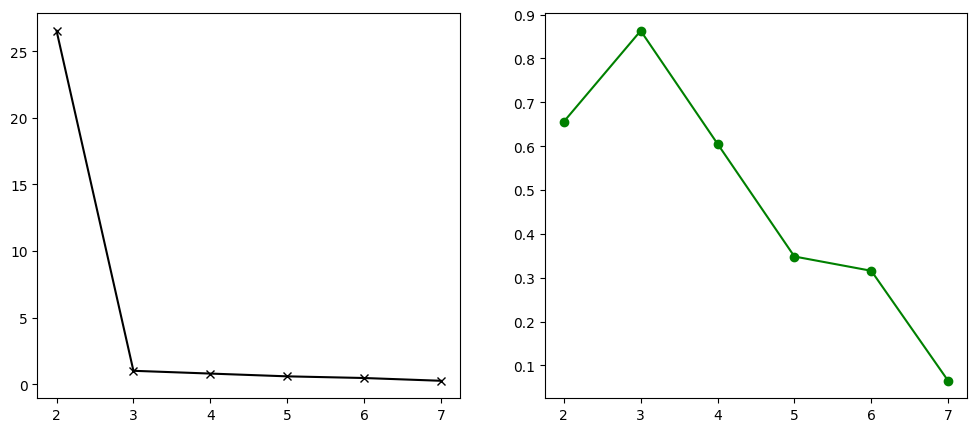

In [47]:
wcss_vals = []
sil_vals = []
possible_k = range(2, min(8, len(X))) if len(X) > 2 else [2]

for k in possible_k:
    model = SimpleKMeans(n_clusters=k).fit(X)
    
    inertia = 0
    for i in range(k):
        cluster_pts = X[model.labels == i]
        if len(cluster_pts) > 0:
            inertia += np.sum((cluster_pts - model.centroids[i])**2)
    wcss_vals.append(inertia)
    
    if len(np.unique(model.labels)) > 1:
        sil_vals.append(silhouette_score(X, model.labels))
    else:
        sil_vals.append(-1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(possible_k, wcss_vals, marker='x', c='black')
ax2.plot(possible_k, sil_vals, marker='o', c='green')
plt.show()

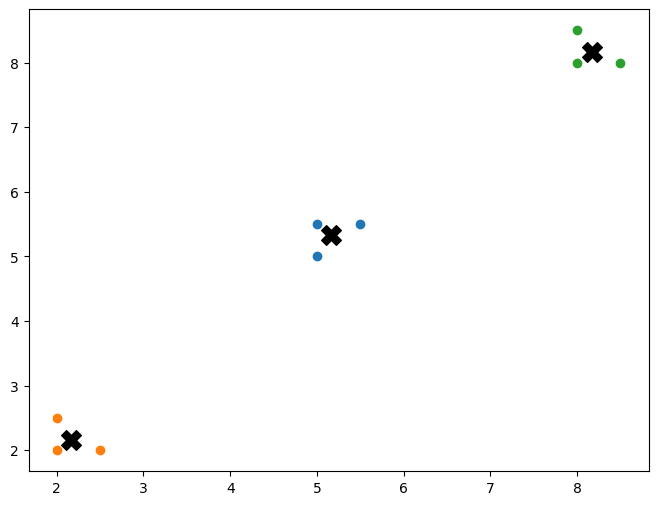

In [48]:
best_k = possible_k[np.argmax(sil_vals)]
final_model = SimpleKMeans(n_clusters=best_k).fit(X)

plt.figure(figsize=(8, 6))
for i in range(best_k):
    cluster_data = X[final_model.labels == i]
    plt.scatter(cluster_data[:, 0], cluster_data[:, 1])
plt.scatter(final_model.centroids[:, 0], final_model.centroids[:, 1], c='black', s=200, marker='X')
plt.show()

In [49]:
class SimpleDBSCAN:
    def __init__(self, eps, min_samples):
        self.eps = eps
        self.min_samples = min_samples
        
    def fit(self, X):
        self.labels = np.full(X.shape[0], -1)
        cluster_id = 0
        
        for i in range(X.shape[0]):
            if self.labels[i] != -1:
                continue
                
            neighbors = self._region_query(X, i)
            
            if len(neighbors) < self.min_samples:
                self.labels[i] = -2
            else:
                self._expand_cluster(X, i, neighbors, cluster_id)
                cluster_id += 1
                
        self.labels[self.labels == -2] = -1
        return self
        
    def _region_query(self, X, p_idx):
        return np.where(np.linalg.norm(X - X[p_idx], axis=1) <= self.eps)[0].tolist()
        
    def _expand_cluster(self, X, p_idx, neighbors, cluster_id):
        self.labels[p_idx] = cluster_id
        i = 0
        while i < len(neighbors):
            n_idx = neighbors[i]
            
            if self.labels[n_idx] == -2:
                self.labels[n_idx] = cluster_id
            elif self.labels[n_idx] == -1:
                self.labels[n_idx] = cluster_id
                new_neighbors = self._region_query(X, n_idx)
                if len(new_neighbors) >= self.min_samples:
                    neighbors.extend(new_neighbors)
            i += 1

DBSCAN Labels: [-1 -1 -1 -1 -1 -1 -1 -1 -1]


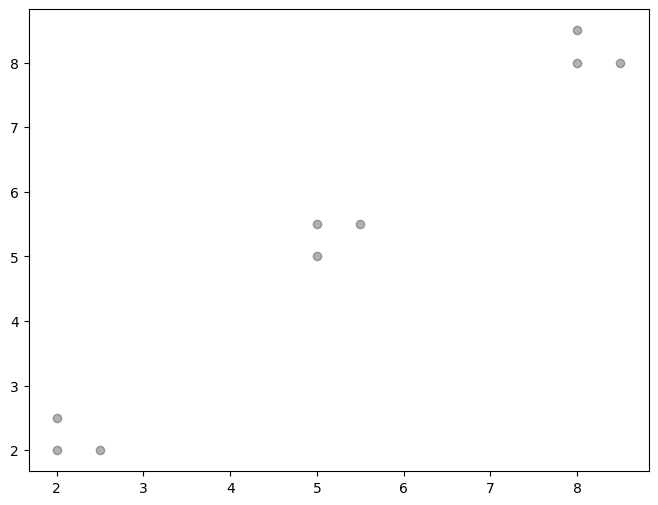

In [50]:
dbscan = SimpleDBSCAN(eps=1.3, min_samples=4).fit(X)
print("DBSCAN Labels:", dbscan.labels)

plt.figure(figsize=(8, 6))
unique_labels = np.unique(dbscan.labels)

for lbl in unique_labels:
    mask = dbscan.labels == lbl
    if lbl == -1:
        plt.scatter(X[mask, 0], X[mask, 1], c='black', alpha=0.3)
    else:
        plt.scatter(X[mask, 0], X[mask, 1])
        
plt.show()